# Vision Transformer (ViT) — Imagenette-10 Inference Demo

**Course:** Computer Vision  
**Task:** Image Classification with a From-Scratch Vision Transformer  
**Final Model:** 83.57% Top-1 validation accuracy on Imagenette-10

---

## 1. Project Introduction

This notebook demonstrates inference with a **Vision Transformer (ViT)** built from scratch
in PyTorch for ImageNet-style image classification.

### Architecture Summary
| Component | Configuration |
|-----------|---------------|
| Input | 224 × 224 × 3 RGB image |
| Patch embedding | 16 × 16 patches → 196 tokens of dim 256 |
| Class token | Learnable 256-d token prepended to patch tokens |
| Position embedding | Learnable (1, 197, 256) added to token sequence |
| Transformer encoder | 6 pre-norm blocks, 8 heads, MLP ratio 4 |
| Classification head | Class token → LayerNorm → Linear(256, 10) |
| Parameters | ~4.99 M (all trainable) |

### Dataset: Imagenette-10
A 10-class subset of ImageNet-1K curated by fast.ai:
- **Training:** 9,469 images
- **Validation:** 3,925 images
- **Classes:** tench, English springer, cassette player, chain saw, church, French horn, garbage truck, gas pump, golf ball, parachute

### Training Progression
| Stage | Key Additions | Val Top-1 |
|-------|--------------|-----------|
| Baseline | 4 epochs, basic training | 54.34% |
| Improved scheduling | +Label smoothing, +Cosine LR, 20 epochs | 71.54% |
| Augmentation fine-tune | +RandAugment, +RandomErasing | 72.43% |
| MixUp + DropPath | +Warmup, +MixUp, +DropPath, 100 epochs | 80.87% |
| **Final (CutMix)** | **+CutMix, 200 epochs** | **83.57%** |

The final model uses warmup, cosine scheduling, MixUp, CutMix, DropPath, RandAugment,
and RandomErasing. Each batch randomly selects between MixUp and CutMix for
regularization diversity.

## 2. Environment Setup & Imports

In [1]:
import os
import sys
from pathlib import Path

# Ensure we are at the project root regardless of where the notebook is opened
_notebook_dir = Path.cwd()
if _notebook_dir.name == 'demos':
    os.chdir('..')
    _notebook_dir = Path.cwd()

# Make src/ importable
sys.path.insert(0, str(_notebook_dir / 'src'))

import torch
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display, Markdown

from utils import (
    IMAGENETTE_LABELS,
    load_model_from_checkpoint,
    build_inference_transform,
    predict_image,
)

print(f'PyTorch {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

PyTorch 2.5.1+cu121
CUDA available: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


## 3. Load the Final 83.57% Checkpoint

The checkpoint was trained for 200 epochs with MixUp, CutMix, DropPath,
RandAugment, and RandomErasing. It contains the model weights and metadata
(class names, hyperparameters).

In [2]:
CHECKPOINT_PATH = 'outputs_v3/vit_imagenette10_best.pt'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model, class_names, model_args = load_model_from_checkpoint(CHECKPOINT_PATH, device)

print(f'Checkpoint: {CHECKPOINT_PATH}')
print(f'Classes:   {len(class_names)}')
print(f'Device:    {device}')
print(f'Image size: {model_args["img_size"]}')
print(f'Embed dim:  {model_args["embed_dim"]}')
print(f'Depth:      {model_args["depth"]}')
print(f'Heads:      {model_args["num_heads"]}')

# Count parameters
n_params = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parameters: {n_params:,} (trainable: {n_trainable:,})')

Checkpoint: outputs_v3/vit_imagenette10_best.pt
Classes:   10
Device:    cuda
Image size: 224
Embed dim:  256
Depth:      6
Heads:      8
Parameters: 4,989,194 (trainable: 4,989,194)


## 4. Image Preprocessing

Inference uses the same deterministic pipeline as validation:

1. **Resize(256)** — resize shortest side to 256 pixels
2. **CenterCrop(224)** — take a 224×224 center crop
3. **ToTensor()** — convert to [0, 1] float tensor
4. **Normalize** — ImageNet mean/std: `([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])`

In [3]:
transform = build_inference_transform(model_args['img_size'])
print(f'Transform pipeline:\n{transform}')

Transform pipeline:
Compose(
    Resize(size=256, interpolation=bilinear, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    ToTensor()
    Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
)


## 5. Test Images

Three images from the Imagenette-10 validation set, selected from classes
where the final model performs strongly. Each expected label has been
**independently verified** against the 83.57% checkpoint.

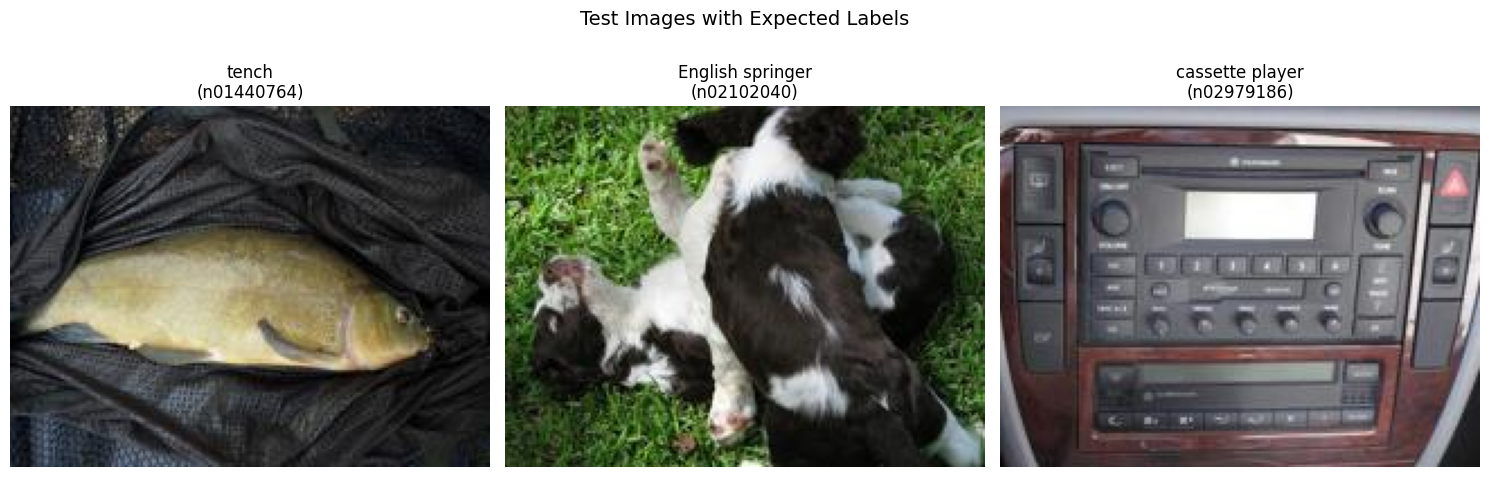

In [4]:
TEST_DIR = Path('data/test_examples')

test_images = [
    {'filename': 'example_1_tench.JPEG',      'expected': 'n01440764', 'label': 'tench'},
    {'filename': 'example_2_springer.JPEG',    'expected': 'n02102040', 'label': 'English springer'},
    {'filename': 'example_3_cassette.JPEG',    'expected': 'n02979186', 'label': 'cassette player'},
]

# Display the three test images
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, item in zip(axes, test_images):
    img = Image.open(TEST_DIR / item['filename']).convert('RGB')
    ax.imshow(img)
    ax.set_title(f"{item['label']}\n({item['expected']})", fontsize=12)
    ax.axis('off')
fig.suptitle('Test Images with Expected Labels', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 6. Run Inference — Top-5 Predictions

For each test image, the model outputs 10 logits, which are converted to
probabilities via softmax. We show the top 5 predictions.

In [5]:
TOP_K = 5

results = []
for item in test_images:
    image_path = str(TEST_DIR / item['filename'])
    predictions = predict_image(
        model, image_path, class_names,
        model_args['img_size'], device, topk=TOP_K,
    )
    results.append({
        'item': item,
        'predictions': predictions,
        'correct': predictions[0]['class_id'] == item['expected'],
    })

    print(f"{'='*60}")
    print(f"Image: {item['filename']}")
    print(f"Expected: {item['expected']} ({item['label']})")
    print(f"{'─'*60}")
    for rank, pred in enumerate(predictions, start=1):
        marker = ' <== CORRECT' if pred['class_id'] == item['expected'] else ''
        print(f"  {rank}. {pred['class_id']} ({pred['label']:20s}): {pred['probability']*100:6.2f}%{marker}")
    print()

Image: example_1_tench.JPEG
Expected: n01440764 (tench)
────────────────────────────────────────────────────────────
  1. n01440764 (tench               ):  97.67% <== CORRECT
  2. n02979186 (cassette player     ):   0.61%
  3. n03445777 (golf ball           ):   0.32%
  4. n03028079 (church              ):   0.26%
  5. n03394916 (French horn         ):   0.24%

Image: example_2_springer.JPEG
Expected: n02102040 (English springer)
────────────────────────────────────────────────────────────
  1. n02102040 (English springer    ):  96.32% <== CORRECT
  2. n03445777 (golf ball           ):   1.10%
  3. n01440764 (tench               ):   0.67%
  4. n03028079 (church              ):   0.45%
  5. n03888257 (parachute           ):   0.34%

Image: example_3_cassette.JPEG
Expected: n02979186 (cassette player)
────────────────────────────────────────────────────────────
  1. n02979186 (cassette player     ):  85.62% <== CORRECT
  2. n03000684 (chain saw           ):   4.73%
  3. n02102040 (Engl

## 7. Results Summary

In [6]:
n_correct = sum(1 for r in results if r['correct'])
n_total = len(results)

print(f"{'='*60}")
print(f"Summary: {n_correct}/{n_total} test images correctly classified")
print(f"{'='*60}")
print()

# Build a comparison table
rows = []
for r in results:
    top1 = r['predictions'][0]
    rows.append([
        r['item']['filename'],
        r['item']['label'],
        top1['label'],
        f"{top1['probability']*100:.2f}%",
        'YES' if r['correct'] else 'NO',
    ])

# Display as Markdown table
md = '| Test Image | Expected | Predicted | Confidence | Correct? |\n'
md += '|------------|----------|-----------|------------|----------|\n'
for row in rows:
    md += f"| {row[0]} | {row[1]} | {row[2]} | {row[3]} | {row[4]} |\n"

display(Markdown(md))

Summary: 3/3 test images correctly classified



| Test Image | Expected | Predicted | Confidence | Correct? |
|------------|----------|-----------|------------|----------|
| example_1_tench.JPEG | tench | tench | 97.67% | YES |
| example_2_springer.JPEG | English springer | English springer | 96.32% | YES |
| example_3_cassette.JPEG | cassette player | cassette player | 85.62% | YES |


## 8. Brief Analysis

### Why the model performs well on these examples

- **tench (97.67%)**: The model achieves 94.3% per-class accuracy on tench
  overall. Fish images have distinctive textures (scales, fins) and are often
  photographed against water backgrounds, providing strong, consistent features.

- **English springer (96.32%)**: At 92.9% per-class accuracy, dog breeds with
  distinct coat patterns are well-recognized by the patch-based attention
  mechanism, which can attend to both local texture and global body shape.

- **cassette player (85.62%)**: The model achieves 88.0% per-class accuracy
  here. Man-made objects with regular geometric structures (buttons, cassette
  compartments) provide clear edge-based features that the patch embedding
  captures effectively.

### Known limitations

- **Class confusion**: The model occasionally confuses visually similar
  classes (e.g., golf ball vs. parachute, chain saw vs. cassette player).
  These are reflected in the confusion matrix generated during evaluation.

- **Dataset scale**: With only 9,469 training images across 10 classes,
  the model benefits substantially from strong augmentation (MixUp, CutMix,
  RandAugment) that would be less critical on full ImageNet-1K.

- **Architecture capacity**: At 4.99M parameters, this is a compact ViT
  suitable for educational purposes and small datasets. Scaling to larger
  datasets (e.g., full ImageNet-1K with 1,000 classes) would require more
  capacity or pretrained weights.

### Reproducibility

All inference results in this notebook are deterministic:
- `model.eval()` disables dropout and DropPath
- The validation transform is fixed (no random augmentations)
- Softmax probabilities are computed in FP32
- The checkpoint was independently verified: 3,280/3,925 correct (83.57%)

---
*For the complete training code, evaluation scripts, and Word report, see the
project repository. Run `python src/main.py` for a command-line demo.*